# Detecção de Síndrome dos Ovários Policísticos (SOP/PCOS)
## Tech Challenge - Fase 1 | Pós Tech IADT

### Contexto do Problema

A Síndrome dos Ovários Policísticos (SOP) é uma das desordens endócrinas mais comuns em mulheres em idade reprodutiva, afetando entre 6% e 12% dessa população. A condição está associada a irregularidades menstruais, hiperandrogenismo, infertilidade, e riscos aumentados de diabetes tipo 2, doenças cardiovasculares e problemas de saúde mental.

O diagnóstico precoce é fundamental para o manejo adequado, mas pode ser complexo por envolver múltiplos critérios clínicos, laboratoriais e ultrassonográficos. Este projeto desenvolve um sistema de Machine Learning para auxiliar profissionais de saúde na identificação de pacientes com PCOS, atuando como ferramenta de suporte ao diagnóstico.

**Dataset**: [Polycystic Ovary Syndrome (PCOS) - Kaggle](https://www.kaggle.com/datasets/prasoonkottarathil/polycystic-ovary-syndrome-pcos)

**Target**: `PCOS (Y/N)` - classificação binária (0 = sem PCOS, 1 = com PCOS)

---

## 1. Imports e Configurações

In [2]:
# Instalar dependências caso necessário
# Descomente as linhas abaixo se algum pacote não estiver instalado
import subprocess
subprocess.run(['pip', 'install', 'xgboost', 'shap', 'openpyxl'], check=True)
print('Dependências verificadas. Se houver erro de import, descomente as linhas acima.')

Dependências verificadas. Se houver erro de import, descomente as linhas acima.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, precision_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42
print('Imports carregados com sucesso.')
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

Imports carregados com sucesso.


## 2. Carregamento e Exploração dos Dados (EDA)

### 2.1 Carregamento

In [5]:
df = pd.read_excel('PCOS_data_without_infertility.xlsx', sheet_name='Full_new')
print(f'Dataset carregado: {df.shape[0]} registros, {df.shape[1]} colunas')
df.head()

Dataset carregado: 541 registros, 45 colunas


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    int64  
 15  

### 2.2 Limpeza inicial dos nomes de colunas e remoção de colunas irrelevantes

In [7]:
# Remover coluna vazia e identificadores
cols_to_drop = ['Unnamed: 44', 'Sl. No', 'Patient File No.']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

# Limpar espaços nos nomes de colunas
df.columns = df.columns.str.strip()

print(f'Após limpeza: {df.shape[0]} registros, {df.shape[1]} colunas')
print(f'\nColunas:\n{list(df.columns)}')

Após limpeza: 541 registros, 42 colunas

Colunas:
['PCOS (Y/N)', 'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI', 'Blood Group', 'Pulse rate(bpm)', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions', 'I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)']


### 2.3 Estatísticas Descritivas

In [8]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
PCOS (Y/N),541.0,0.33,0.47,0.00,0.00,0.00,1.00,1.00
Age (yrs),541.0,31.43,5.41,20.00,28.00,31.00,35.00,48.00
Weight (Kg),541.0,59.64,11.03,31.00,52.00,59.00,65.00,108.00
Height(Cm),541.0,156.48,6.03,137.00,152.00,156.00,160.00,180.00
BMI,541.0,24.31,4.06,12.42,21.64,24.24,26.63,38.90
Blood Group,541.0,13.80,1.84,11.00,13.00,14.00,15.00,18.00
Pulse rate(bpm),541.0,73.25,4.43,13.00,72.00,72.00,74.00,82.00
RR (breaths/min),541.0,19.24,1.69,16.00,18.00,18.00,20.00,28.00
Hb(g/dl),541.0,11.16,0.87,8.50,10.50,11.00,11.70,14.80
Cycle(R/I),541.0,2.56,0.90,2.00,2.00,2.00,4.00,5.00


In [9]:
# Verificar valores ausentes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Ausentes': missing, '%': missing_pct})
print('Valores ausentes:')
missing_df[missing_df['Ausentes'] > 0]

Valores ausentes:


,Ausentes,%
Marraige Status (Yrs),1,0.18
Fast food (Y/N),1,0.18


In [10]:
# Verificar tipos de dados — AMH e II beta-HCG são object, precisam conversão
print('Colunas com tipo object:')
print(df.select_dtypes(include='object').columns.tolist())
print()
print('Amostra de AMH(ng/mL):', df['AMH(ng/mL)'].head(10).values)
print('Amostra de II beta-HCG:', df['II    beta-HCG(mIU/mL)'].head(10).values)

Colunas com tipo object:
['II    beta-HCG(mIU/mL)', 'AMH(ng/mL)']

Amostra de AMH(ng/mL): [2.07 1.53 6.63 1.22 2.26 6.74 3.05 1.54 1 1.61]
Amostra de II beta-HCG: [1.99 1.99 494.08 1.99 801.45 1.99 1.99 100.51 1.99 1.99]


### 2.4 Distribuição da Variável Alvo

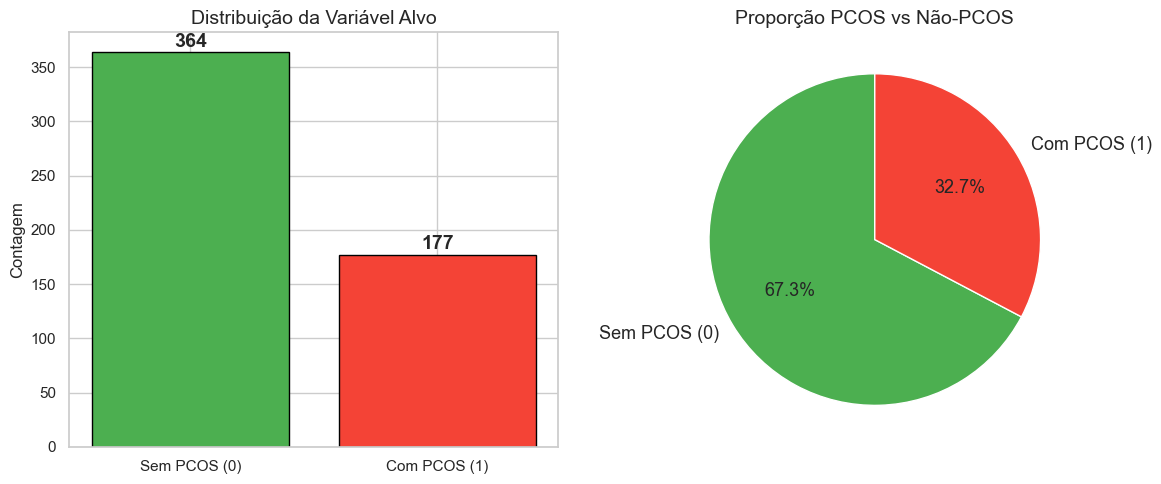


Classe 0 (Sem PCOS): 364 (67.3%)
Classe 1 (Com PCOS): 177 (32.7%)
Razão de desbalanceamento: 2.06:1


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Contagem
target_counts = df['PCOS (Y/N)'].value_counts()
labels = ['Sem PCOS (0)', 'Com PCOS (1)']
colors = ['#4CAF50', '#F44336']

axes[0].bar(labels, target_counts.values, color=colors, edgecolor='black')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=14)
axes[0].set_title('Distribuição da Variável Alvo', fontsize=14)
axes[0].set_ylabel('Contagem')

# Percentual
axes[1].pie(target_counts.values, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 13})
axes[1].set_title('Proporção PCOS vs Não-PCOS', fontsize=14)

plt.tight_layout()
plt.savefig('fig_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nClasse 0 (Sem PCOS): {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)')
print(f'Classe 1 (Com PCOS): {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)')
print(f'Razão de desbalanceamento: {target_counts[0]/target_counts[1]:.2f}:1')

**Discussão**: O dataset apresenta um desbalanceamento moderado (cerca de 2:1), com 67.3% sem PCOS e 32.7% com PCOS. Isso é relevante pois métricas como acurácia podem ser enganosas — priorizaremos **Recall** e **F1-Score**, já que em um contexto médico é crucial minimizar falsos negativos (deixar de identificar uma paciente com PCOS).

### 2.5 Distribuições das Features Numéricas

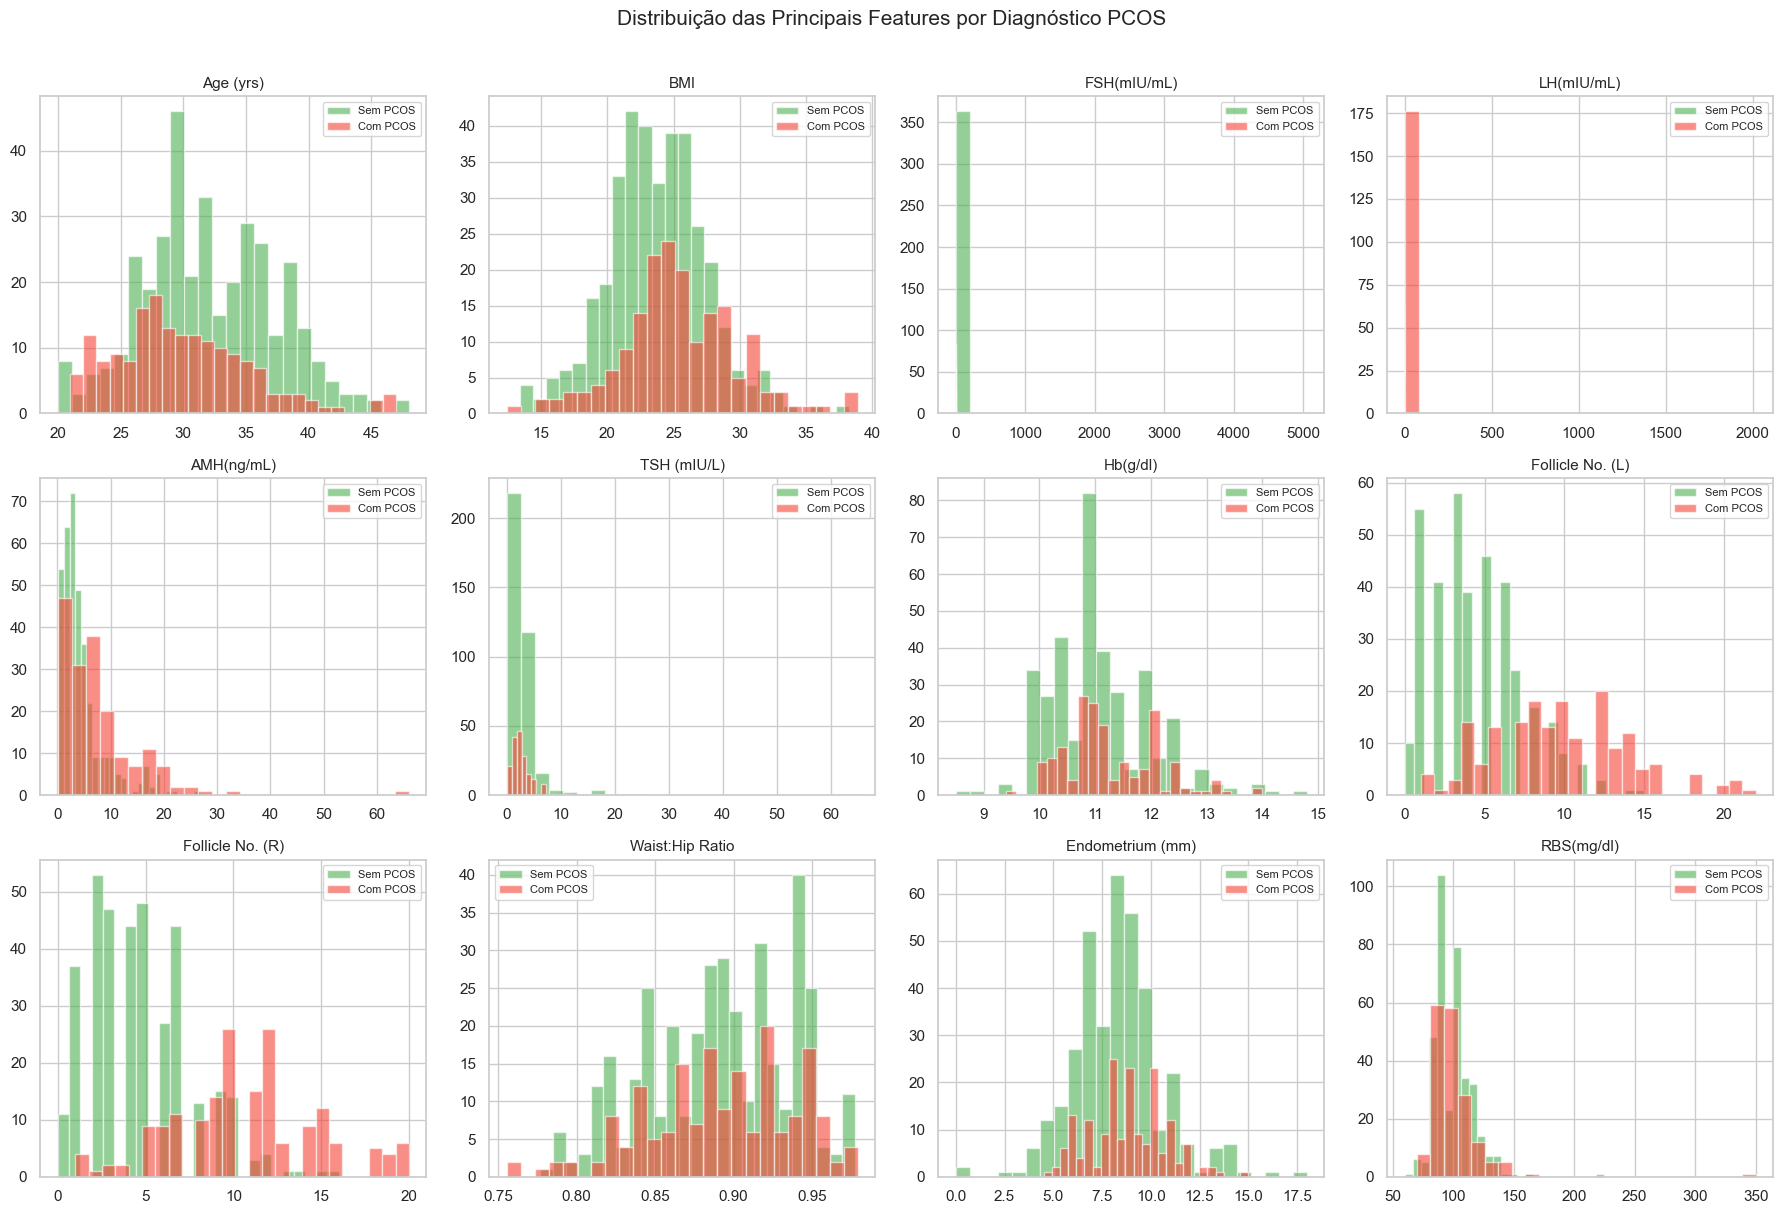

In [12]:
# Converter colunas object para numérico
df['II    beta-HCG(mIU/mL)'] = pd.to_numeric(df['II    beta-HCG(mIU/mL)'], errors='coerce')
df['AMH(ng/mL)'] = pd.to_numeric(df['AMH(ng/mL)'], errors='coerce')

# Separar features numéricas contínuas das binárias
binary_cols = ['PCOS (Y/N)', 'Pregnant(Y/N)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
               'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
               'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'Cycle(R/I)']

numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in binary_cols]

# Histogramas das principais features contínuas
key_features = ['Age (yrs)', 'BMI', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'AMH(ng/mL)',
                'TSH (mIU/L)', 'Hb(g/dl)', 'Follicle No. (L)', 'Follicle No. (R)',
                'Waist:Hip Ratio', 'Endometrium (mm)', 'RBS(mg/dl)']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for i, col in enumerate(key_features):
    ax = axes[i // 4, i % 4]
    for label, color in zip([0, 1], ['#4CAF50', '#F44336']):
        subset = df[df['PCOS (Y/N)'] == label][col].dropna()
        ax.hist(subset, bins=25, alpha=0.6, color=color,
                label='Sem PCOS' if label == 0 else 'Com PCOS')
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('Distribuição das Principais Features por Diagnóstico PCOS', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('fig_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Discussão**: Observa-se que pacientes com PCOS tendem a apresentar:
- **Maior número de folículos** (L e R) — consistente com a definição clínica da síndrome
- **Maior AMH** — o hormônio anti-Mulleriano é elevado em PCOS
- **Maior LH** — o LH elevado é um marcador clássico de PCOS
- **BMI ligeiramente mais alto** — associação conhecida entre PCOS e sobrepeso
- **Maior razão cintura-quadril** — refletindo distribuição de gordura andróide

Esses padrões são consistentes com a literatura médica sobre PCOS.

### 2.6 Análise das Features Binárias (Sintomas)

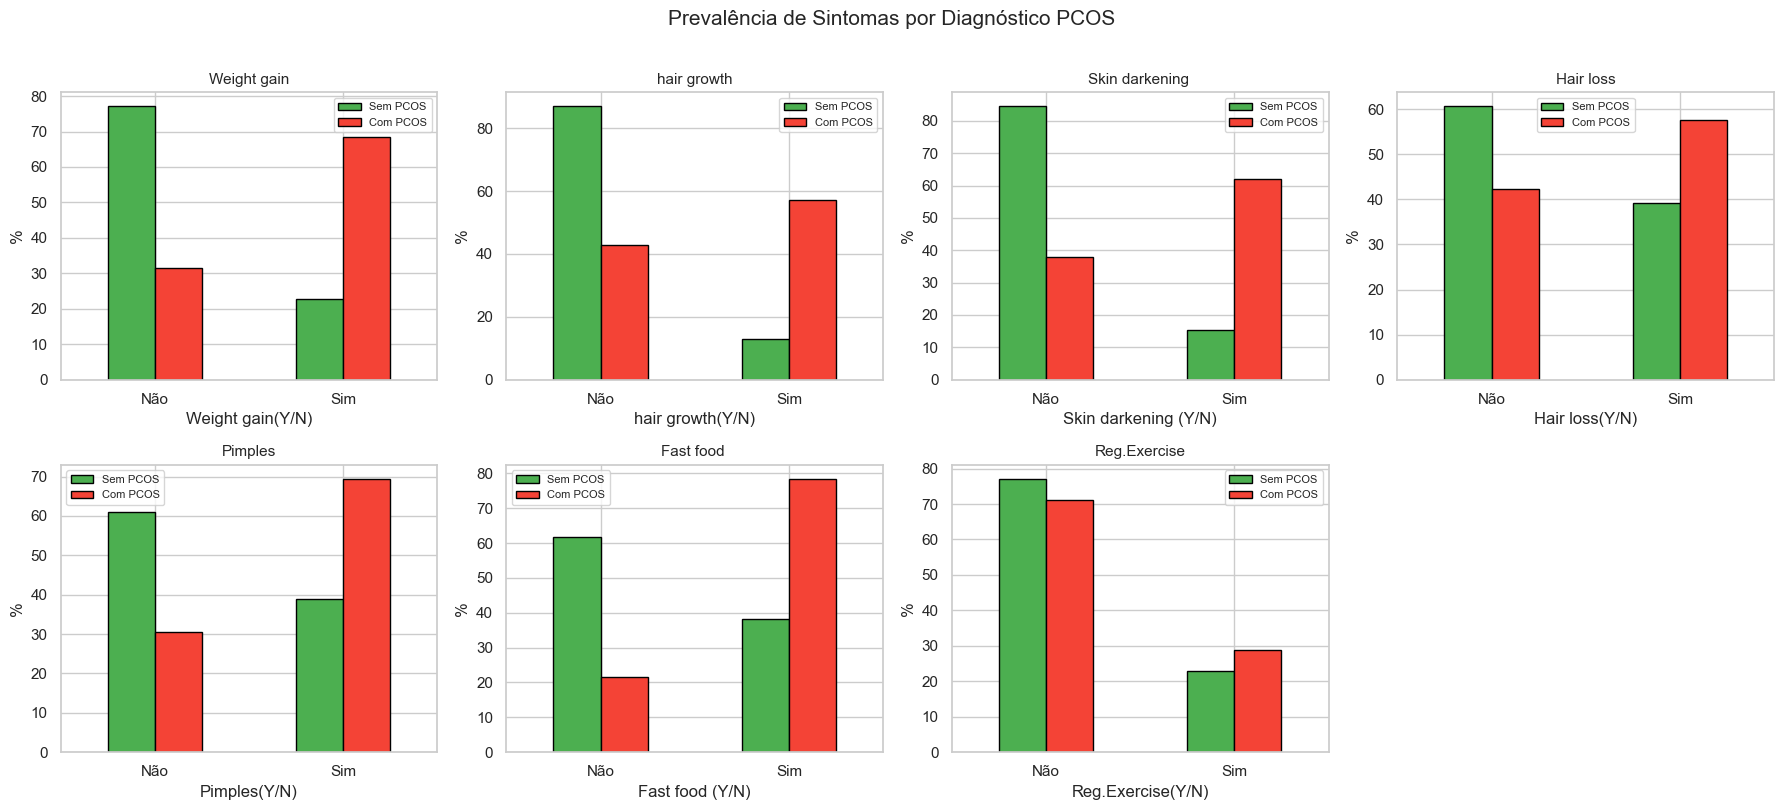

In [13]:
symptom_cols = ['Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
                'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(symptom_cols):
    ct = pd.crosstab(df[col], df['PCOS (Y/N)'], normalize='columns') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#4CAF50', '#F44336'], edgecolor='black')
    axes[i].set_title(col.replace('(Y/N)', ''), fontsize=11)
    axes[i].set_ylabel('%')
    axes[i].set_xticklabels(['Não', 'Sim'], rotation=0)
    axes[i].legend(['Sem PCOS', 'Com PCOS'], fontsize=8)

axes[-1].axis('off')
plt.suptitle('Prevalência de Sintomas por Diagnóstico PCOS', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('fig_symptoms.png', dpi=150, bbox_inches='tight')
plt.show()

**Discussão**: Pacientes com PCOS apresentam maior prevalência de ganho de peso, crescimento excessivo de pelos (hirsutismo), escurecimento da pele (acantose nigricans) e espinhas — todos sintomas clássicos do hiperandrogenismo associado à SOP.

### 2.7 Boxplots Comparativos

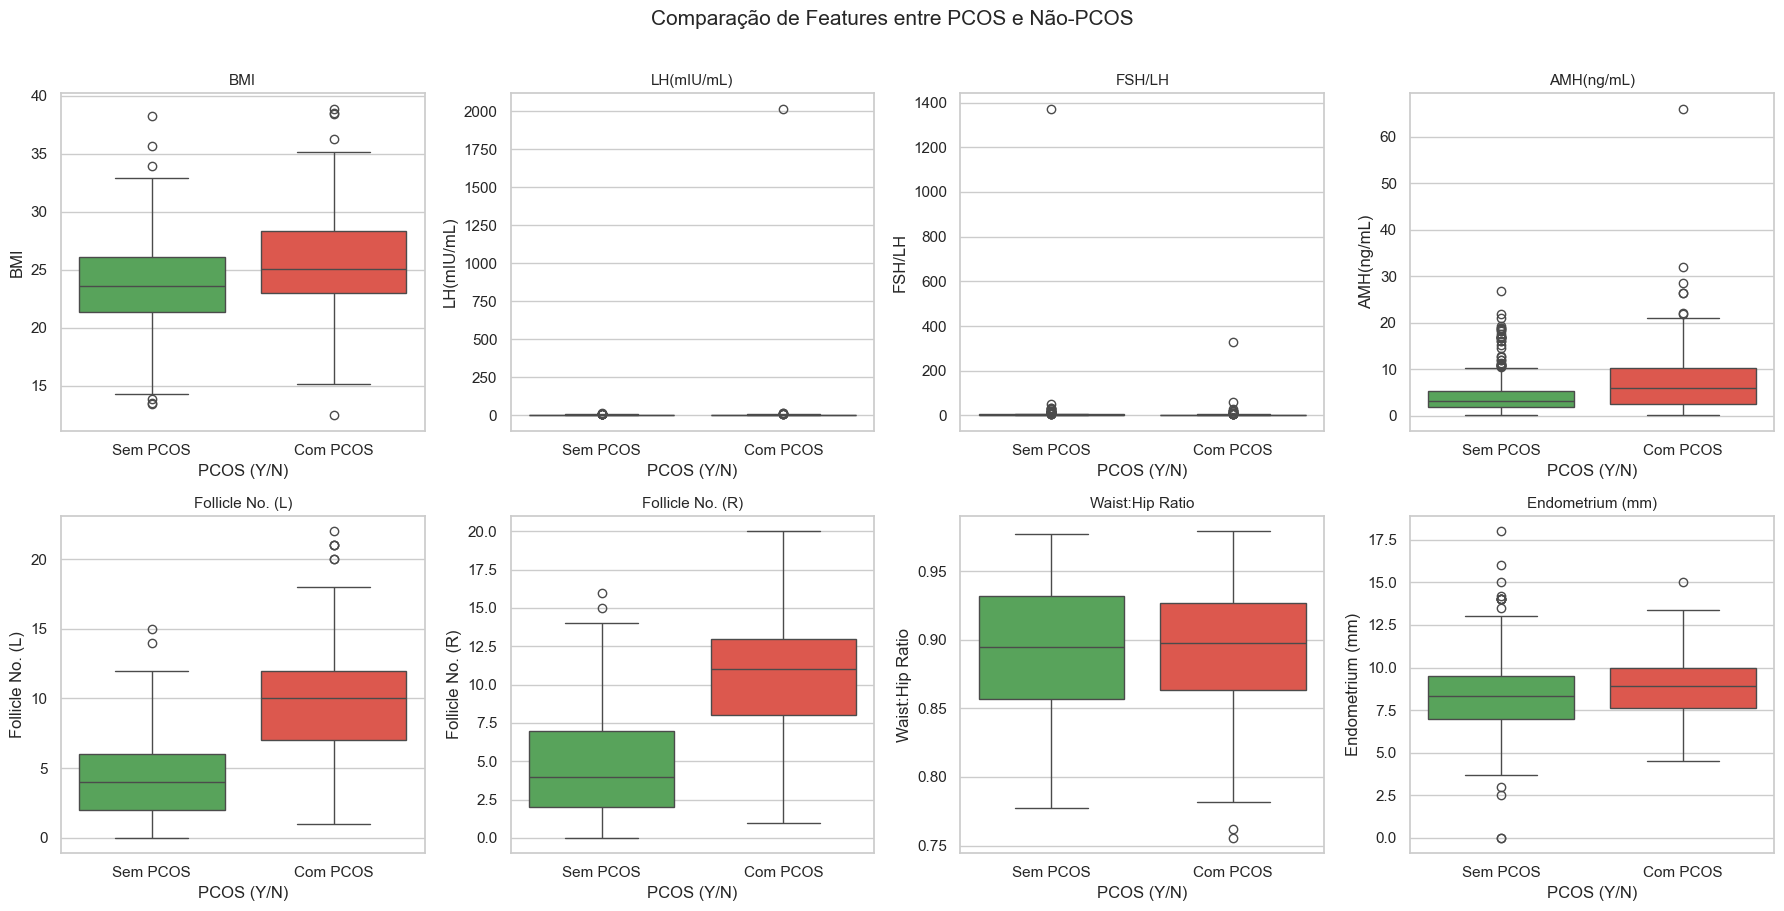

In [14]:
key_box = ['BMI', 'LH(mIU/mL)', 'FSH/LH', 'AMH(ng/mL)',
           'Follicle No. (L)', 'Follicle No. (R)', 'Waist:Hip Ratio', 'Endometrium (mm)']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for i, col in enumerate(key_box):
    ax = axes[i // 4, i % 4]
    sns.boxplot(data=df, x='PCOS (Y/N)', y=col, ax=ax,
                palette={0: '#4CAF50', 1: '#F44336'}, hue='PCOS (Y/N)', legend=False)
    ax.set_xticklabels(['Sem PCOS', 'Com PCOS'])
    ax.set_title(col, fontsize=11)

plt.suptitle('Comparação de Features entre PCOS e Não-PCOS', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('fig_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Pré-processamento de Dados

### 3.1 Tratamento de Valores Ausentes e Inconsistentes

In [15]:
print('Valores ausentes antes do tratamento:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print()

# Preencher valores ausentes com a mediana (robusto a outliers)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f'  {col}: preenchido com mediana = {median_val}')

print(f'\nValores ausentes após tratamento: {df.isnull().sum().sum()}')

Valores ausentes antes do tratamento:
Marraige Status (Yrs)     1
II    beta-HCG(mIU/mL)    1
AMH(ng/mL)                1
Fast food (Y/N)           1
dtype: int64

  Marraige Status (Yrs): preenchido com mediana = 7.0
  II    beta-HCG(mIU/mL): preenchido com mediana = 1.99
  AMH(ng/mL): preenchido com mediana = 3.7
  Fast food (Y/N): preenchido com mediana = 1.0

Valores ausentes após tratamento: 0


### 3.2 Pipeline de Pré-processamento

In [16]:
# Separar target e features
target = 'PCOS (Y/N)'
X = df.drop(columns=[target])
y = df[target]

# Blood Group é categórico ordinal (codificado como inteiro 11-18 no dataset)
# As demais variáveis já estão em formato numérico adequado
print(f'Features: {X.shape[1]}')
print(f'Amostras: {X.shape[0]}')
print(f'\nTipos de dados das features:')
print(X.dtypes.value_counts())

Features: 41
Amostras: 541

Tipos de dados das features:
float64    21
int64      20
Name: count, dtype: int64


In [17]:
# Verificar se há valores infinitos
inf_count = np.isinf(X.select_dtypes(include=[np.number])).sum().sum()
print(f'Valores infinitos: {inf_count}')

# Garantir que todas as colunas são numéricas
X = X.apply(pd.to_numeric, errors='coerce')
X.fillna(X.median(), inplace=True)

print(f'Shape final: {X.shape}')
print(f'Tipos: {X.dtypes.unique()}')

Valores infinitos: 0
Shape final: (541, 41)
Tipos: [dtype('int64') dtype('float64')]


### 3.3 Análise de Correlação

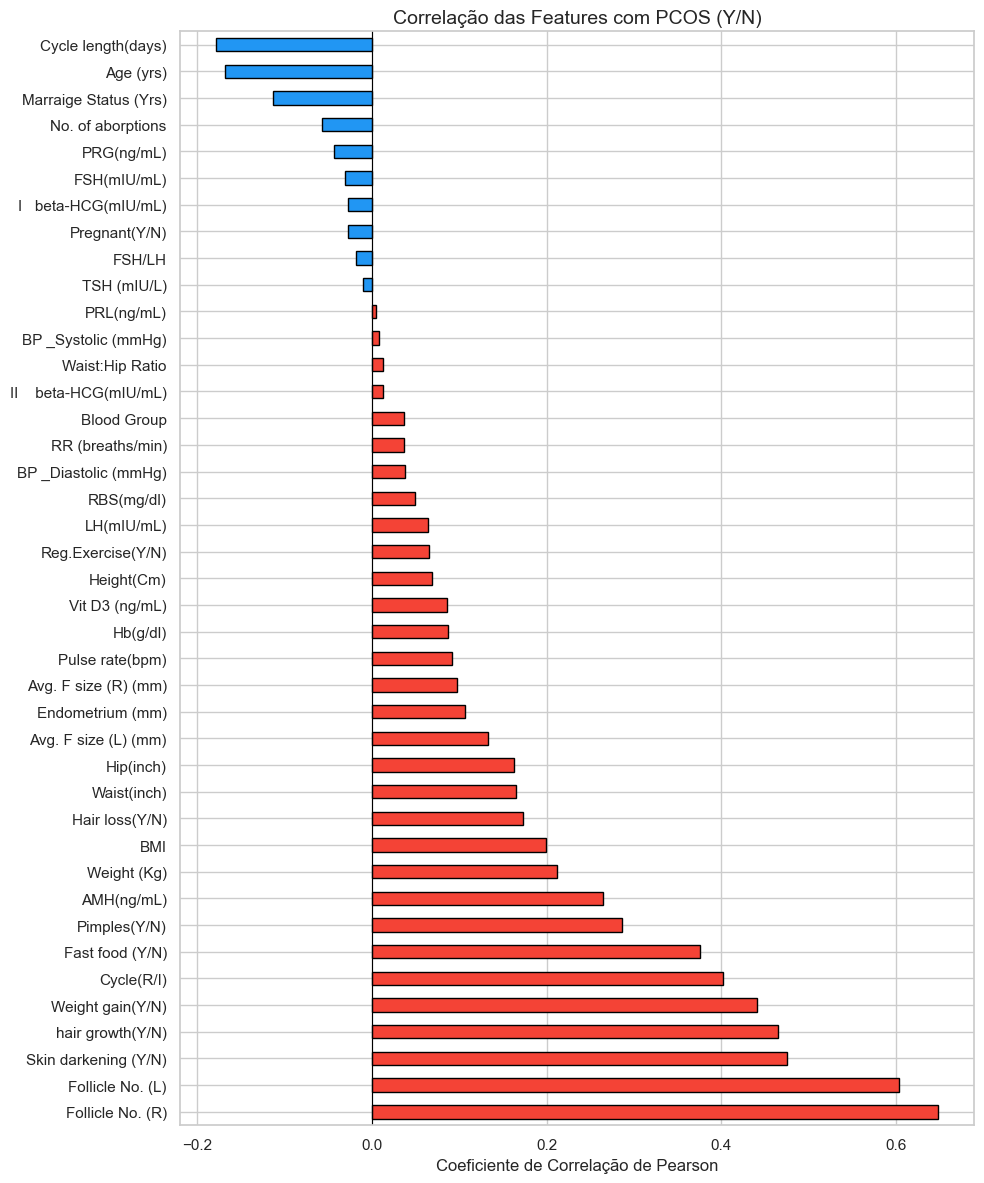

Top 10 features mais correlacionadas com PCOS:
Follicle No. (R)        0.648
Follicle No. (L)        0.603
Skin darkening (Y/N)    0.476
hair growth(Y/N)        0.465
Weight gain(Y/N)        0.441
Cycle(R/I)              0.402
Fast food (Y/N)         0.376
Pimples(Y/N)            0.286
AMH(ng/mL)              0.264
Weight (Kg)             0.212
Name: PCOS (Y/N), dtype: float64


In [18]:
# Correlação com a variável alvo
df_corr = X.copy()
df_corr[target] = y
corr_target = df_corr.corr()[target].drop(target).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#F44336' if v > 0 else '#2196F3' for v in corr_target.values]
corr_target.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title('Correlação das Features com PCOS (Y/N)', fontsize=14)
ax.set_xlabel('Coeficiente de Correlação de Pearson')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('fig_correlation_target.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features mais correlacionadas com PCOS:')
print(corr_target.abs().sort_values(ascending=False).head(10).round(3))

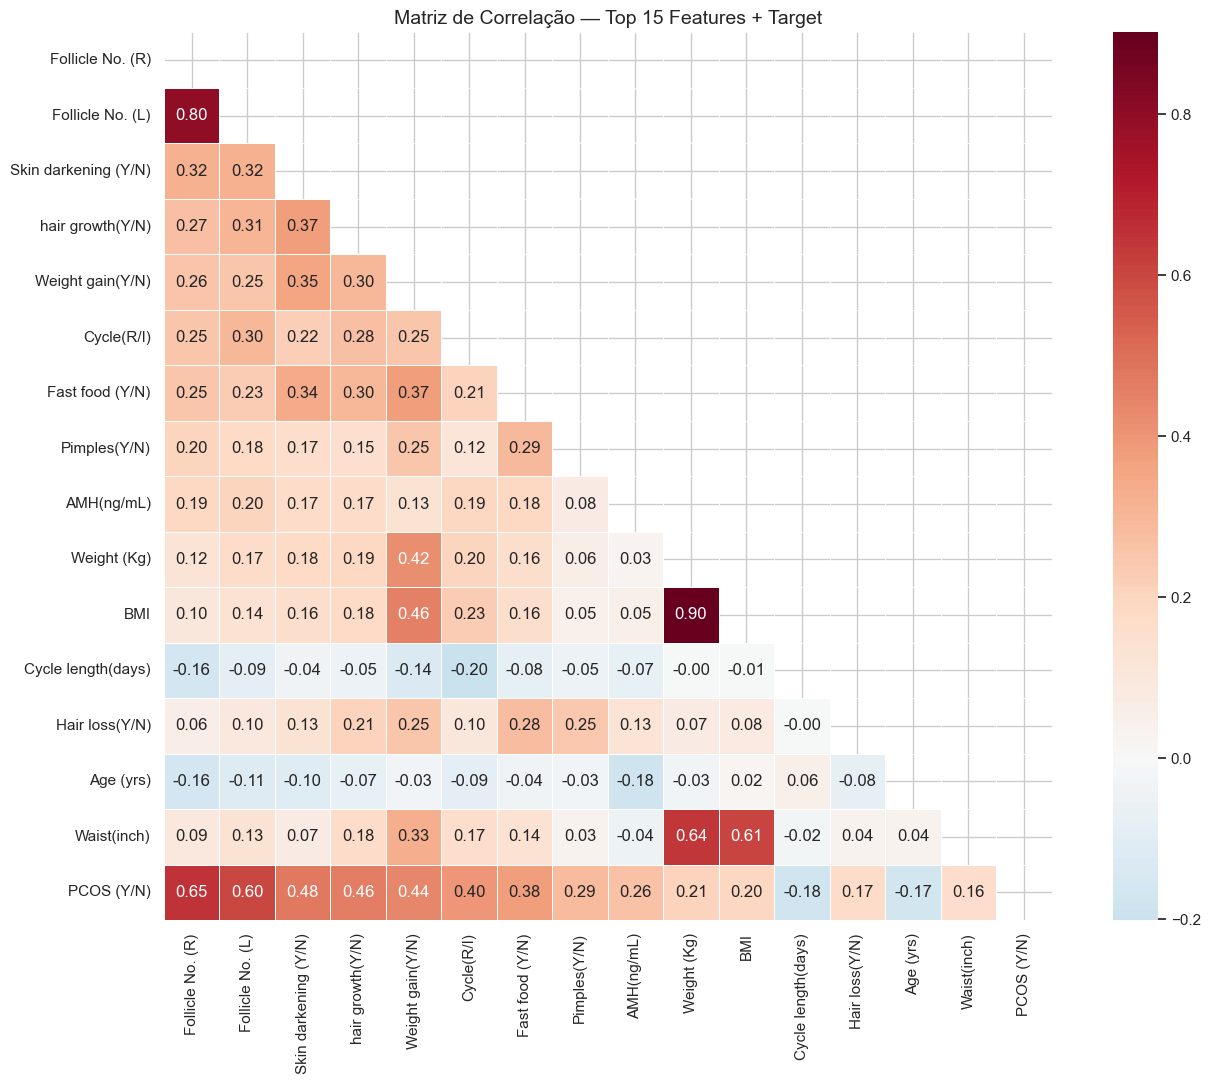

In [19]:
# Mapa de calor das correlações entre features (top 15 mais correlacionadas com target)
top_features = corr_target.abs().sort_values(ascending=False).head(15).index.tolist()
top_features_with_target = top_features + [target]

fig, ax = plt.subplots(figsize=(14, 11))
corr_matrix = df_corr[top_features_with_target].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Matriz de Correlação — Top 15 Features + Target', fontsize=14)
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Discussão da Correlação**:
- **Follicle No. (L) e (R)** são as features mais correlacionadas com PCOS — esperado, pois ovários policísticos são definidos pelo excesso de folículos
- **Skin darkening, hair growth, Weight gain** (sintomas de hiperandrogenismo) têm correlação positiva significativa
- **AMH** (hormônio anti-Mulleriano) é elevado em PCOS — correlação positiva
- **Cycle(R/I)** — ciclo irregular fortemente associado a PCOS
- Existe **multicolinearidade** entre Follicle No. L e R, e entre BMI e Weight — isso será tratado pelo modelo ou pode ser monitorado

### 3.4 Seleção de Features

Com base na correlação de Pearson calculada na seção anterior, removemos as features com **correlação absoluta < 0.1** com a variável alvo `PCOS (Y/N)`. 
Esse limiar elimina features que adicionam ruído sem contribuir com poder preditivo, reduzindo overfitting e simplificando os modelos.

A seleção é feita **antes** da separação treino/teste para que todos os modelos usem o mesmo conjunto reduzido de features.

In [20]:
# ── Seleção de Features por Correlação com o Target ──────────────────────────
CORR_THRESHOLD = 0.1  # limiar de correlação absoluta mínima

df_corr_sel = X.copy()
df_corr_sel[target] = y
corr_with_target = df_corr_sel.corr()[target].drop(target)

# Features selecionadas (correlação absoluta >= limiar)
selected_features = corr_with_target[corr_with_target.abs() >= CORR_THRESHOLD].index.tolist()
dropped_features  = corr_with_target[corr_with_target.abs() <  CORR_THRESHOLD].index.tolist()

print(f'Features originais : {X.shape[1]}')
print(f'Features selecionadas (|corr| >= {CORR_THRESHOLD}): {len(selected_features)}')
print(f'Features removidas : {len(dropped_features)}')
print(f'\nFeatures removidas por baixa correlação:')
for feat in dropped_features:
    print(f'  {feat}: {corr_with_target[feat]:.4f}')

# Aplicar seleção
X = X[selected_features]
print(f'\nShape de X após seleção: {X.shape}')

Features originais : 41
Features selecionadas (|corr| >= 0.1): 19
Features removidas : 22

Features removidas por baixa correlação:
  Height(Cm): 0.0683
  Blood Group: 0.0364
  Pulse rate(bpm): 0.0918
  RR (breaths/min): 0.0369
  Hb(g/dl): 0.0872
  Pregnant(Y/N): -0.0276
  No. of aborptions: -0.0572
  I   beta-HCG(mIU/mL): -0.0276
  II    beta-HCG(mIU/mL): 0.0128
  FSH(mIU/mL): -0.0303
  LH(mIU/mL): 0.0639
  FSH/LH: -0.0183
  Waist:Hip Ratio: 0.0124
  TSH (mIU/L): -0.0101
  PRL(ng/mL): 0.0051
  Vit D3 (ng/mL): 0.0855
  PRG(ng/mL): -0.0438
  RBS(mg/dl): 0.0489
  Reg.Exercise(Y/N): 0.0653
  BP _Systolic (mmHg): 0.0079
  BP _Diastolic (mmHg): 0.0380
  Avg. F size (R) (mm): 0.0977

Shape de X após seleção: (541, 19)


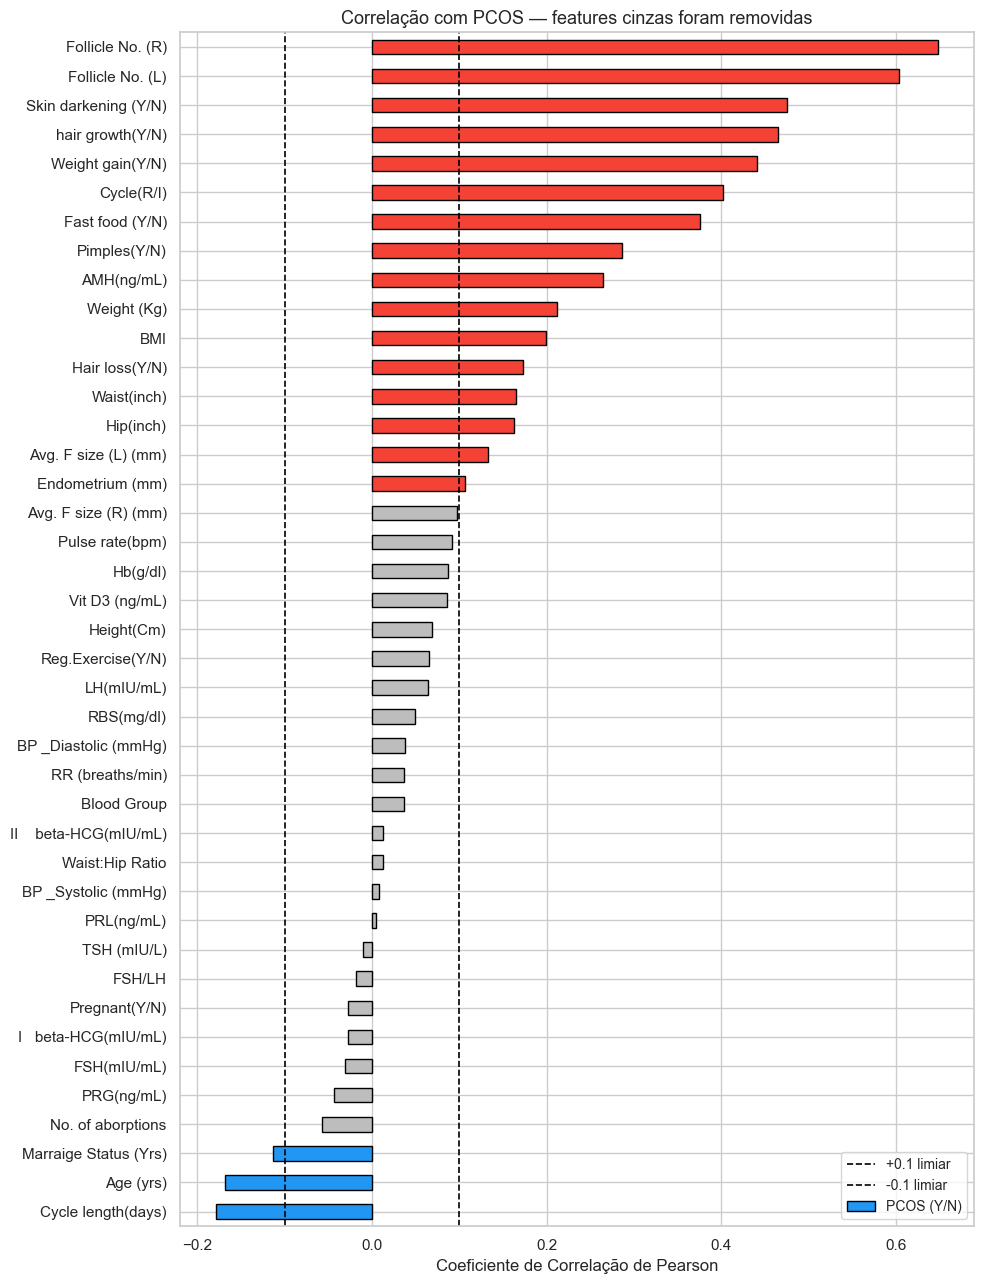

Gráfico salvo.


In [21]:
# Visualizar correlações — destacando as removidas
fig, ax = plt.subplots(figsize=(10, 13))

colors = [
    '#F44336' if corr_with_target[f] > 0 else '#2196F3'
    if f in selected_features else '#BDBDBD'
    for f in corr_with_target.sort_values().index
]

corr_sorted = corr_with_target.sort_values()
bar_colors = [
    ('#F44336' if v > 0 else '#2196F3') if f in selected_features else '#BDBDBD'
    for f, v in corr_sorted.items()
]

corr_sorted.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='black')
ax.axvline(x= CORR_THRESHOLD, color='black', linewidth=1.2, linestyle='--', label=f'+{CORR_THRESHOLD} limiar')
ax.axvline(x=-CORR_THRESHOLD, color='black', linewidth=1.2, linestyle='--', label=f'-{CORR_THRESHOLD} limiar')
ax.set_title('Correlação com PCOS — features cinzas foram removidas', fontsize=13)
ax.set_xlabel('Coeficiente de Correlação de Pearson')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Gráfico salvo.')

### 3.5 Separação Treino/Teste e Normalização

In [22]:
# Separação estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Treino: {X_train.shape[0]} amostras')
print(f'Teste:  {X_test.shape[0]} amostras')
print(f'\nDistribuição no treino: {y_train.value_counts().to_dict()}')
print(f'Distribuição no teste:  {y_test.value_counts().to_dict()}')

Treino: 432 amostras
Teste:  109 amostras

Distribuição no treino: {0: 291, 1: 141}
Distribuição no teste:  {0: 73, 1: 36}


In [23]:
# Normalização (StandardScaler) — necessário para Logistic Regression e KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converter de volta para DataFrame para facilitar visualização
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print('Dados normalizados com StandardScaler.')
print(f'Média das features (treino): ~{X_train_scaled.mean().mean():.4f}')
print(f'Std das features (treino):   ~{X_train_scaled.std().mean():.4f}')

Dados normalizados com StandardScaler.
Média das features (treino): ~-0.0000
Std das features (treino):   ~1.0012


---
## 4. Modelagem

### Escolha dos Modelos

Selecionamos **5 algoritmos de classificação** com características complementares:

1. **Regressão Logística** — modelo linear baseline, interpretável, bom para entender relações lineares
2. **KNN (K-Nearest Neighbors)** — modelo baseado em instância, captura padrões não-lineares locais
3. **Árvore de Decisão** — modelo baseado em regras, altamente interpretável
4. **Random Forest** — ensemble de árvores, reduz overfitting e melhora generalização
5. **XGBoost** — gradient boosting, estado da arte para dados tabulares

A escolha de múltiplos modelos permite comparar abordagens e identificar o melhor equilíbrio entre performance e interpretabilidade.

In [24]:
# Definir modelos
models = {
    'Regressão Logística': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'Árvore de Decisão': DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200, max_depth=10),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE, n_estimators=200, max_depth=5,
                             learning_rate=0.1, eval_metric='logloss', verbosity=0)
}

# Para Logistic Regression e KNN usamos dados normalizados
# Para modelos baseados em árvore, dados originais
scaled_models = {'Regressão Logística', 'KNN'}

print(f'{len(models)} modelos definidos.')

5 modelos definidos.


### 4.1 Treinamento com Validação Cruzada

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in models.items():
    X_tr = X_train_scaled if name in scaled_models else X_train
    
    scores_acc = cross_val_score(model, X_tr, y_train, cv=cv, scoring='accuracy')
    scores_f1 = cross_val_score(model, X_tr, y_train, cv=cv, scoring='f1')
    scores_recall = cross_val_score(model, X_tr, y_train, cv=cv, scoring='recall')
    
    cv_results[name] = {
        'Accuracy': f'{scores_acc.mean():.4f} ± {scores_acc.std():.4f}',
        'F1-Score': f'{scores_f1.mean():.4f} ± {scores_f1.std():.4f}',
        'Recall': f'{scores_recall.mean():.4f} ± {scores_recall.std():.4f}',
        'acc_mean': scores_acc.mean(),
        'f1_mean': scores_f1.mean(),
        'recall_mean': scores_recall.mean()
    }
    print(f'{name:25s} | Acc: {scores_acc.mean():.4f} | F1: {scores_f1.mean():.4f} | Recall: {scores_recall.mean():.4f}')

print('\nValidação cruzada concluída.')

Regressão Logística       | Acc: 0.8843 | F1: 0.8194 | Recall: 0.8015
KNN                       | Acc: 0.8658 | F1: 0.7652 | Recall: 0.6736
Árvore de Decisão         | Acc: 0.8150 | F1: 0.7228 | Recall: 0.7232
Random Forest             | Acc: 0.8891 | F1: 0.8221 | Recall: 0.7734
XGBoost                   | Acc: 0.8683 | F1: 0.7981 | Recall: 0.7803

Validação cruzada concluída.


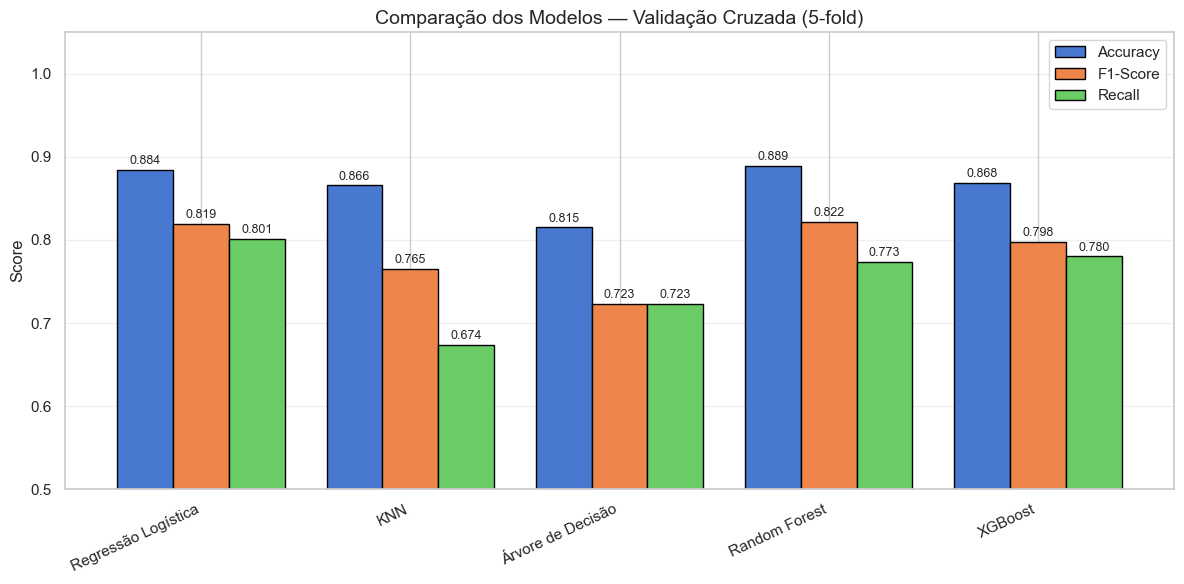

In [26]:
# Visualizar resultados da validação cruzada
cv_df = pd.DataFrame({name: {'Accuracy': v['acc_mean'], 'F1-Score': v['f1_mean'], 'Recall': v['recall_mean']}
                       for name, v in cv_results.items()}).T

fig, ax = plt.subplots(figsize=(12, 6))
cv_df.plot(kind='bar', ax=ax, edgecolor='black', width=0.8)
ax.set_title('Comparação dos Modelos — Validação Cruzada (5-fold)', fontsize=14)
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.05)
ax.set_xticklabels(cv_df.index, rotation=25, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9, padding=2)

plt.tight_layout()
plt.savefig('fig_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Treinamento e Avaliação no Conjunto de Teste

In [27]:
# Treinar todos os modelos e avaliar no conjunto de teste
test_results = {}
trained_models = {}

for name, model in models.items():
    X_tr = X_train_scaled if name in scaled_models else X_train
    X_te = X_test_scaled if name in scaled_models else X_test
    
    model.fit(X_tr, y_train)
    trained_models[name] = model
    
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    
    test_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'y_pred': y_pred,
        'y_proba': y_proba
    }

# Tabela de resultados
results_df = pd.DataFrame({name: {k: v for k, v in vals.items() if k not in ['y_pred', 'y_proba']}
                            for name, vals in test_results.items()}).T.round(4)
results_df = results_df.sort_values('F1-Score', ascending=False)
print('=== Resultados no Conjunto de Teste ===\n')
results_df

=== Resultados no Conjunto de Teste ===



,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Regressão Logística,0.9174,0.8857,0.8611,0.8732,0.9502
Random Forest,0.9174,0.9355,0.8056,0.8657,0.9353
Árvore de Decisão,0.9083,0.9062,0.8056,0.8529,0.9231
KNN,0.9083,0.9333,0.7778,0.8485,0.9555
XGBoost,0.8991,0.8788,0.8056,0.8406,0.9513


### 5.1 Matrizes de Confusão

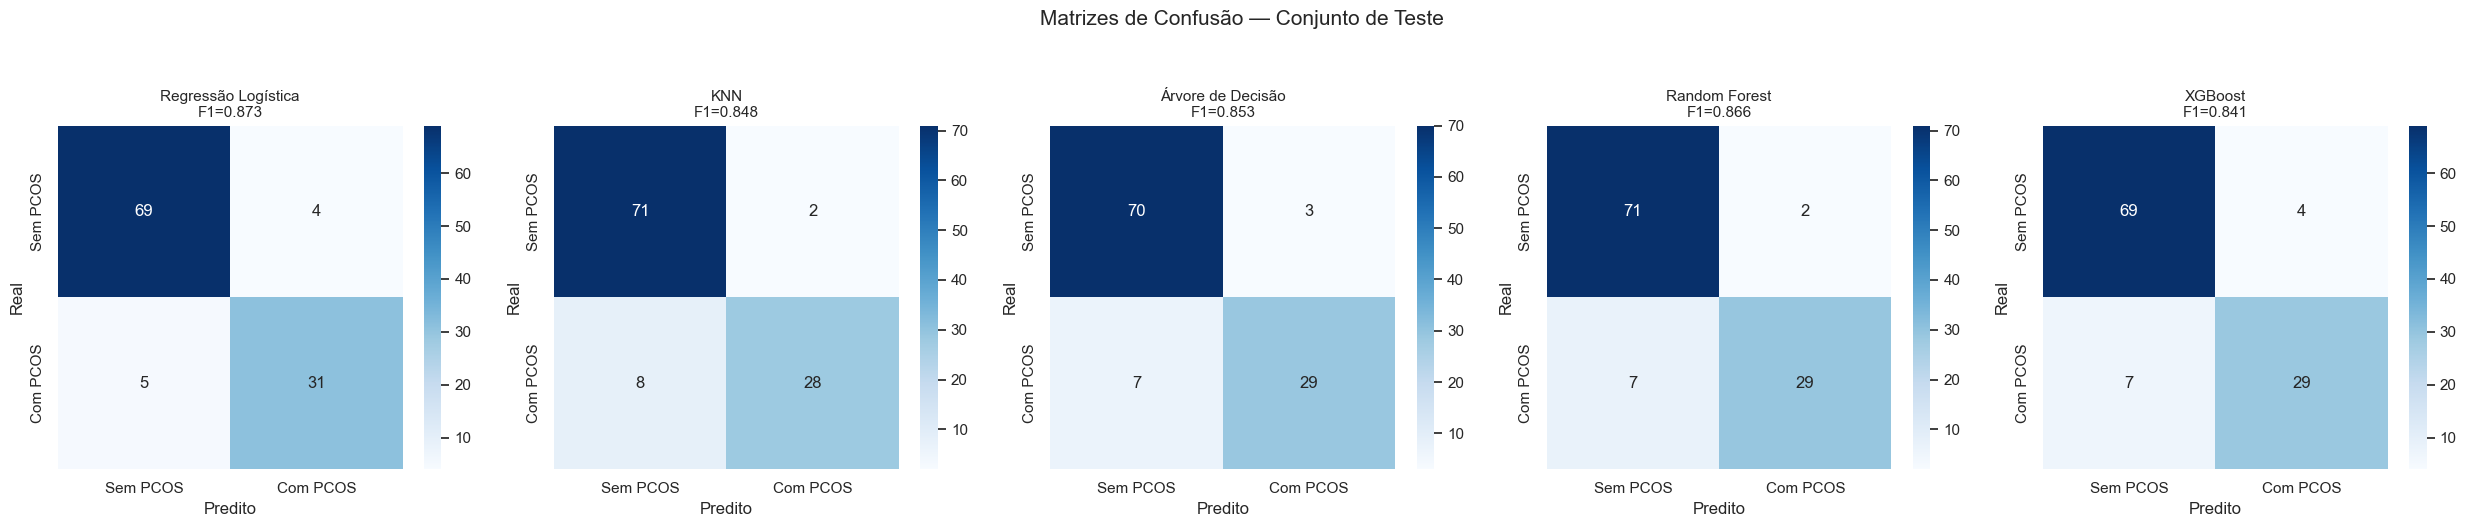

In [28]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, (name, vals) in enumerate(test_results.items()):
    cm = confusion_matrix(y_test, vals['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Sem PCOS', 'Com PCOS'],
                yticklabels=['Sem PCOS', 'Com PCOS'])
    axes[i].set_title(f'{name}\nF1={vals["F1-Score"]:.3f}', fontsize=11)
    axes[i].set_ylabel('Real')
    axes[i].set_xlabel('Predito')

plt.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=15, y=1.05)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Curvas ROC

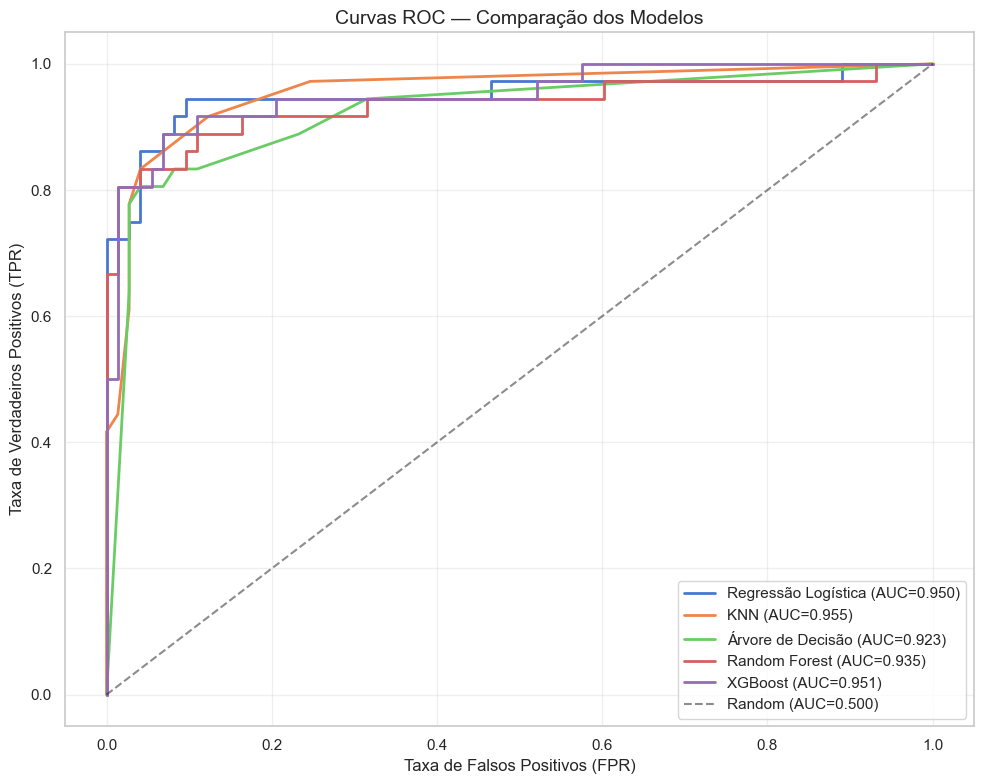

In [29]:
fig, ax = plt.subplots(figsize=(10, 8))

for name, vals in test_results.items():
    fpr, tpr, _ = roc_curve(y_test, vals['y_proba'])
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={vals['AUC-ROC']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.500)')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Comparação dos Modelos', fontsize=14)
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Classification Report do Melhor Modelo

In [30]:
# Identificar melhor modelo pelo F1-Score
best_model_name = results_df.index[0]
best_preds = test_results[best_model_name]['y_pred']

print(f'Melhor modelo: {best_model_name}\n')
print(classification_report(y_test, best_preds,
                            target_names=['Sem PCOS (0)', 'Com PCOS (1)']))

Melhor modelo: Regressão Logística

              precision    recall  f1-score   support

Sem PCOS (0)       0.93      0.95      0.94        73
Com PCOS (1)       0.89      0.86      0.87        36

    accuracy                           0.92       109
   macro avg       0.91      0.90      0.91       109
weighted avg       0.92      0.92      0.92       109



## 5.4 Hyperparameter Optimization

Além da comparação entre modelos, foi realizada uma etapa de otimização de hiperparâmetros utilizando RandomizedSearchCV.

O XGBoost foi selecionado para esta análise por ser um dos algoritmos mais utilizados em problemas de classificação tabular e frequentemente apresentar excelente desempenho em aplicações de Machine Learning para saúde.

A otimização foi conduzida com foco em Recall, métrica prioritária neste contexto devido ao impacto clínico dos falsos negativos no diagnóstico de PCOS.

In [31]:

# Balanceamento da classe positiva
negative_cases = (y_train == 0).sum()
positive_cases = (y_train == 1).sum()
scale_pos_weight = negative_cases / positive_cases

xgb_base = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)

param_dist = {
    'n_estimators': randint(100, 600),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.25),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'min_child_weight': randint(1, 8),
    'gamma': uniform(0, 0.5),
    'scale_pos_weight': [1, scale_pos_weight*0.8, scale_pos_weight, scale_pos_weight*1.2]
}

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_

y_pred_opt = best_xgb.predict(X_test)
y_proba_opt = best_xgb.predict_proba(X_test)[:,1]

optimized_results = {
    'Accuracy': accuracy_score(y_test, y_pred_opt),
    'Precision': precision_score(y_test, y_pred_opt),
    'Recall': recall_score(y_test, y_pred_opt),
    'F1-Score': f1_score(y_test, y_pred_opt),
    'AUC-ROC': roc_auc_score(y_test, y_proba_opt)
}

print("Melhores parâmetros encontrados:")
print(random_search.best_params_)
print("\nMétricas do modelo otimizado:")
print(pd.DataFrame(optimized_results,index=['XGBoost Otimizado']).T)

baseline = pd.Series(test_results['XGBoost']).drop(labels=['y_pred','y_proba'], errors='ignore')
comparison_df = pd.DataFrame({
    'Modelo Base': baseline,
    'Modelo Otimizado': pd.Series(optimized_results)
})
display(comparison_df)


Melhores parâmetros encontrados:
{'colsample_bytree': np.float64(0.8883683244845908), 'gamma': np.float64(0.09713697675602112), 'learning_rate': np.float64(0.027735229249981917), 'max_depth': 8, 'min_child_weight': 6, 'n_estimators': 559, 'scale_pos_weight': np.float64(2.0638297872340425), 'subsample': np.float64(0.8013985470554607)}

Métricas do modelo otimizado:
           XGBoost Otimizado
Accuracy            0.917431
Precision           0.846154
Recall              0.916667
F1-Score            0.880000
AUC-ROC             0.959285


,Modelo Base,Modelo Otimizado
Accuracy,0.899083,0.917431
Precision,0.878788,0.846154
Recall,0.805556,0.916667
F1-Score,0.84058,0.880000
AUC-ROC,0.951294,0.959285


---
## 6. Explicabilidade — Feature Importance e SHAP

### 6.1 Feature Importance (Random Forest)

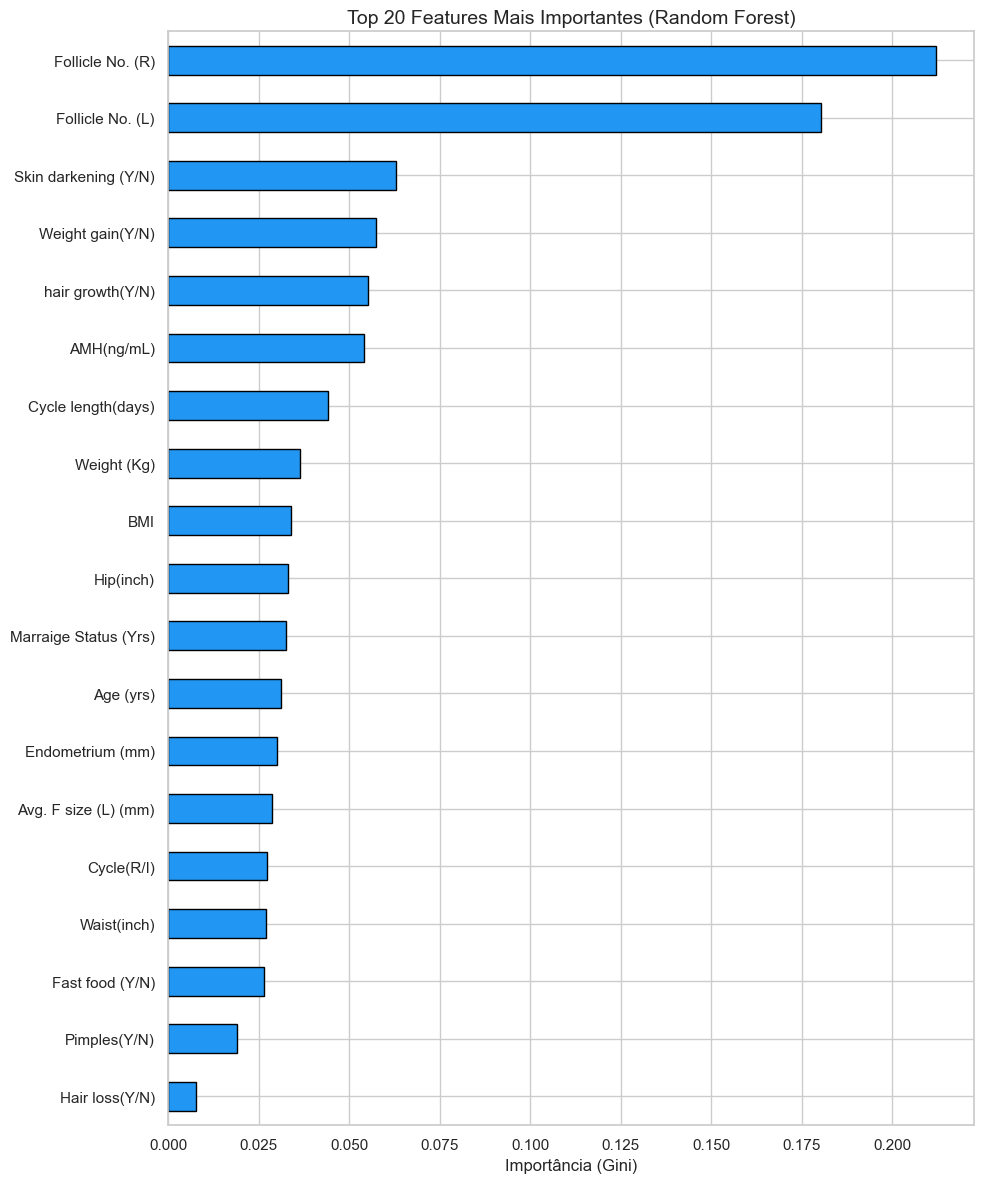

Top 10 features mais importantes:
  Follicle No. (R): 0.2120
  Follicle No. (L): 0.1804
  Skin darkening (Y/N): 0.0628
  Weight gain(Y/N): 0.0575
  hair growth(Y/N): 0.0553
  AMH(ng/mL): 0.0540
  Cycle length(days): 0.0442
  Weight (Kg): 0.0364
  BMI: 0.0340
  Hip(inch): 0.0330


In [32]:
rf_model = trained_models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
importances.tail(20).plot(kind='barh', ax=ax, color='#2196F3', edgecolor='black')
ax.set_title('Top 20 Features Mais Importantes (Random Forest)', fontsize=14)
ax.set_xlabel('Importância (Gini)')
plt.tight_layout()
plt.savefig('fig_feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features mais importantes:')
for feat, imp in importances.tail(10).iloc[::-1].items():
    print(f'  {feat}: {imp:.4f}')

### 6.2 SHAP Values

In [33]:
# SHAP para o modelo XGBoost
xgb_model = best_xgb if 'best_xgb' in globals() else trained_models['XGBoost']
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print('SHAP values calculados.')

SHAP values calculados.


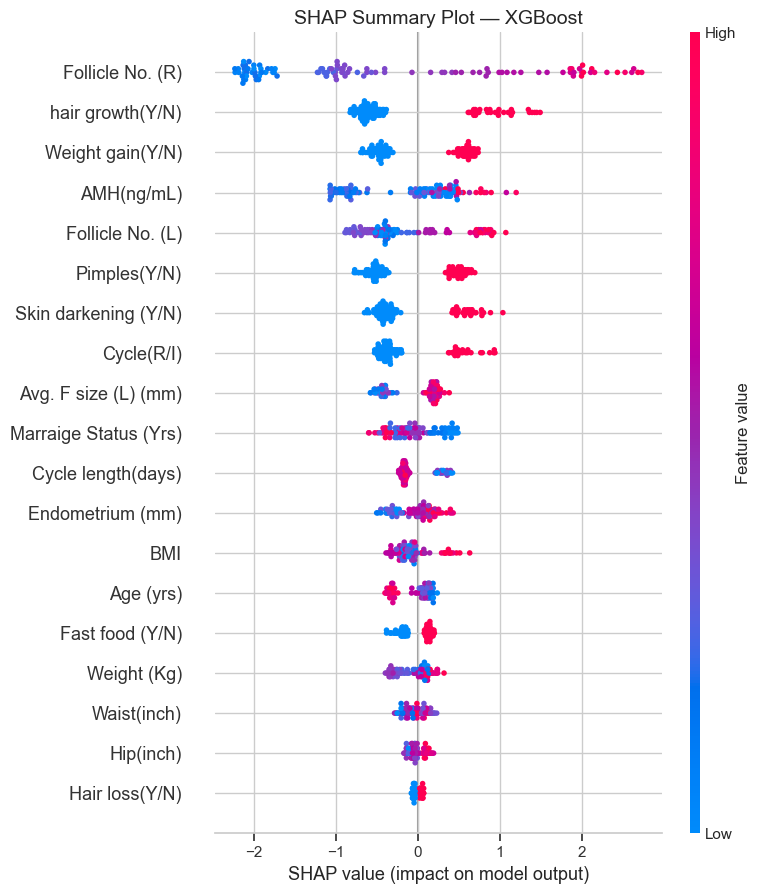

In [34]:
# SHAP Summary Plot
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test, max_display=20, show=False)
plt.title('SHAP Summary Plot — XGBoost', fontsize=14)
plt.tight_layout()
plt.savefig('fig_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

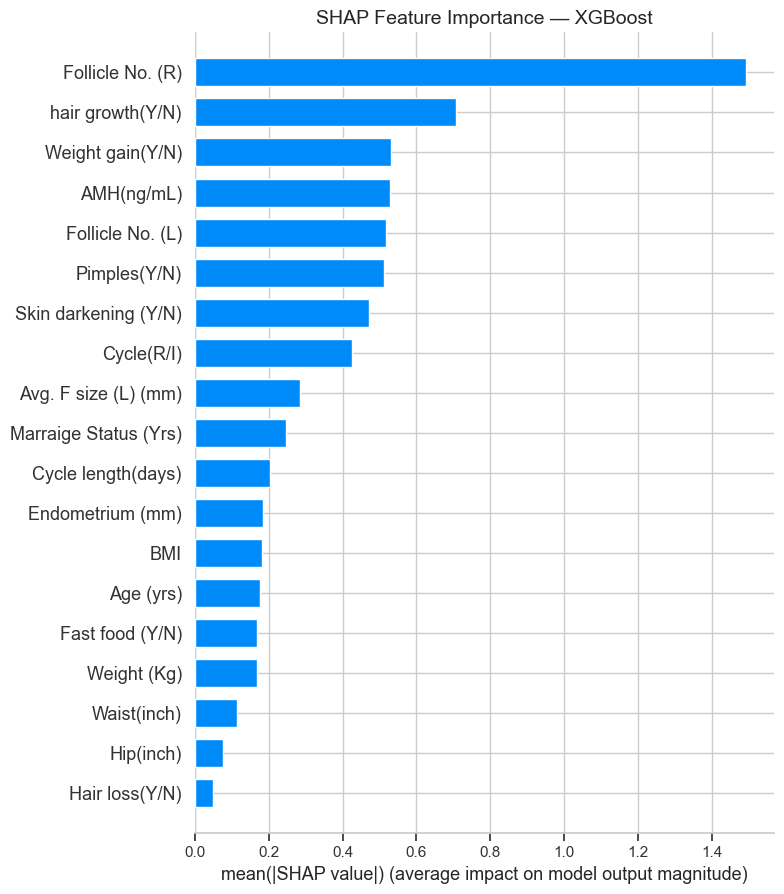

In [35]:
# SHAP Bar Plot (importância média)
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=20, show=False)
plt.title('SHAP Feature Importance — XGBoost', fontsize=14)
plt.tight_layout()
plt.savefig('fig_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

Explicando predição para a paciente no índice 0 do teste:
  Predição: Sem PCOS
  Real:     PCOS



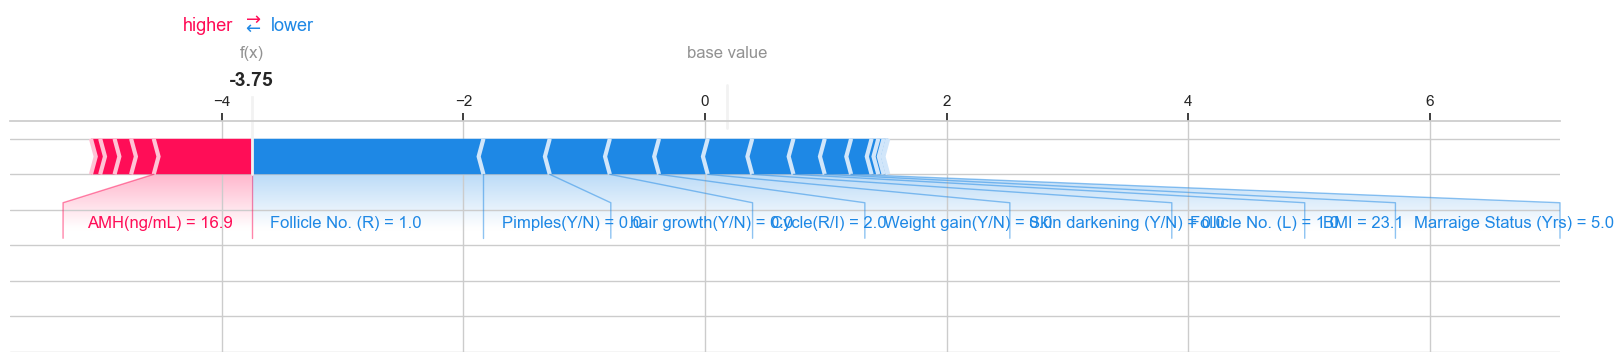

<Figure size 1200x600 with 0 Axes>

In [36]:
# SHAP para uma predição individual (exemplo de explicabilidade local)
sample_idx = 0
print(f'Explicando predição para a paciente no índice {sample_idx} do teste:')
print(f'  Predição: {"PCOS" if test_results["XGBoost"]["y_pred"][sample_idx] == 1 else "Sem PCOS"}')
print(f'  Real:     {"PCOS" if y_test.iloc[sample_idx] == 1 else "Sem PCOS"}')
print()

shap.force_plot(explainer.expected_value, shap_values[sample_idx, :],
                X_test.iloc[sample_idx, :], matplotlib=True)
plt.savefig('fig_shap_force_plot.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretação SHAP**:
- O SHAP confirma que **número de folículos** é o fator mais determinante para o diagnóstico de PCOS
- **Sintomas de hiperandrogenismo** (crescimento de pelos, ganho de peso, escurecimento da pele) têm impacto significativo
- **AMH elevado** empurra a predição para PCOS positivo
- A **regularidade do ciclo menstrual** também é altamente preditiva
- O SHAP permite explicar cada predição individual ao médico, mostrando quais fatores contribuíram para o diagnóstico sugerido

---
## 7. Discussão Crítica dos Resultados

### Performance dos Modelos

Os modelos baseados em ensemble (Random Forest e XGBoost) apresentaram a melhor performance geral, superando os modelos mais simples. Isso é esperado para dados tabulares com interações entre features.

### Escolha da Métrica Principal

Em um contexto médico de **triagem diagnóstica**, priorizamos:
- **Recall (Sensibilidade)**: crucial minimizar falsos negativos — não queremos deixar de identificar pacientes com PCOS
- **F1-Score**: equilíbrio entre Precision e Recall, pois falsos positivos também têm custo (exames desnecessários, ansiedade)
- **AUC-ROC**: capacidade geral de discriminação do modelo

A acurácia sozinha seria insuficiente devido ao desbalanceamento das classes.

### Aplicabilidade Prática

O modelo **pode ser utilizado na prática como ferramenta de apoio ao diagnóstico**, com as seguintes ressalvas:

1. **O médico sempre deve ter a palavra final**: o sistema serve como triagem automatizada, sinalizando pacientes com maior probabilidade de PCOS para investigação mais aprofundada
2. **Não substitui exames clínicos**: os critérios de Rotterdam (2+ de: hiperandrogenismo, anovulação, ovários policísticos ao ultrassom) continuam sendo o padrão-ouro
3. **Explicabilidade**: o SHAP permite que o médico entenda *por que* o modelo sugere determinado diagnóstico, aumentando a confiança na ferramenta
4. **Limitações do dataset**: dados de uma única instituição, possível viés de seleção, tamanho amostral moderado (541 pacientes)

### Possíveis Melhorias Futuras
- Dados de múltiplas instituições para maior generalização
- Inclusão de dados de imagem (ultrassom ovariano) com CNNs
- Validação prospectiva em ambiente clínico real

---
## 8. Resumo Final

In [37]:
print('=' * 60)
print('RESUMO — Tech Challenge Fase 1')
print('Detecção de Síndrome dos Ovários Policísticos (PCOS)')
print('=' * 60)
print(f'\nDataset: 541 pacientes, 42 features')
print(f'Target: PCOS (Y/N) — 67.3% negativo, 32.7% positivo')
print(f'\nModelos avaliados: {len(models)}')
print(f'Melhor modelo: {best_model_name}')
print(f'\n--- Métricas do melhor modelo no teste ---')
for metric, val in test_results[best_model_name].items():
    if metric not in ['y_pred', 'y_proba']:
        print(f'  {metric}: {val:.4f}')
print(f'\nTécnicas de explicabilidade: Feature Importance + SHAP')
print('=' * 60)

RESUMO — Tech Challenge Fase 1
Detecção de Síndrome dos Ovários Policísticos (PCOS)

Dataset: 541 pacientes, 42 features
Target: PCOS (Y/N) — 67.3% negativo, 32.7% positivo

Modelos avaliados: 5
Melhor modelo: Regressão Logística

--- Métricas do melhor modelo no teste ---
  Accuracy: 0.9174
  Precision: 0.8857
  Recall: 0.8611
  F1-Score: 0.8732
  AUC-ROC: 0.9502

Técnicas de explicabilidade: Feature Importance + SHAP
